# Module 3 · Assignment 1 — Supervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.**
It gives you the skeleton of a professional supervised-learning workflow.
Your job is to fill in every `# TODO`, and — more importantly — to *interrogate*
your model and answer the guiding questions in `REPORT.md`.

> The model is the easy 30%. The thinking is the graded 70%.

**Workflow (6 stations):**
0. Frame the problem and pick a success metric
1. Load data, split honestly, build a dumb baseline
2. Train at least 3 model families
3. Evaluate once on the locked test set
4. Interrogate the model (errors, importance, stability)
5. Translate to the real world (Model Card)

Pick **one** task in Part 1. Write all code and comments in **English**.


---
## Part 0 · Frame the problem

Before any code, write in `REPORT.md`:
- The business question in one paragraph.
- The exact target you are predicting.
- The **primary metric** you will optimize, and **why it fits the business cost**
  (what does a false positive cost vs a false negative? for forecasting, what does
  an over- vs under-forecast cost?).

Do not skip this. A model optimized for the wrong metric is worse than no model.


---
## Part 1 · Setup, data, honest split, baseline

In [33]:
# Core imports. Add what you need; keep everything in English.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


### Choose ONE task

Uncomment exactly one loader below. Each returns the raw material you need;
**feature selection and engineering choices are yours** (keep it light — heavy
feature engineering is Module 5).

| Option | Type | Target | Notes |
|---|---|---|---|
| A | Binary classification | `review_score <= 2` (negative review) | The course thread. Try a **time-based split**. |
| B | Binary classification | customer churn | Fresh dataset. No class code to copy. |
| C | Forecasting (regression) | next-day order volume | Time series **as a supervised problem** (Session 18). |


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the path where your Olist CSVs live (the 9-table Kaggle structure from class).
# TODO: point this to your local Olist folder
from google.colab import drive
drive.mount('/content/drive/')
OLIST_DIR = '/content/drive/MyDrive/Brazilian E-Commerce Public Dataset by Olist/'

# ---- Option A · Olist negative-review classification --------------------------
def load_olist_reviews(olist_dir=OLIST_DIR):
    """Join the tables needed to predict a negative review (review_score <= 2).
    Returns a single dataframe. You decide which columns become features."""
    orders   = pd.read_csv(olist_dir + "olist_orders_dataset.csv",
                           parse_dates=["order_purchase_timestamp",
                                        "order_delivered_customer_date",
                                        "order_estimated_delivery_date"])
    reviews  = pd.read_csv(olist_dir + "olist_order_reviews_dataset.csv")
    items    = pd.read_csv(olist_dir + "olist_order_items_dataset.csv")
    payments = pd.read_csv(olist_dir + "olist_order_payments_dataset.csv")

    # One row per order: aggregate items and payments.
    item_agg = (items.groupby("order_id")
                .agg(n_items=("order_item_id", "count"),
                     price_total=("price", "sum"),
                     freight_total=("freight_value", "sum"))
                .reset_index())
    pay_agg = (payments.groupby("order_id")
               .agg(payment_value=("payment_value", "sum"),
                    max_installments=("payment_installments", "max"))
               .reset_index())
    rev = (reviews.sort_values("review_creation_date")
           .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])

    df = (orders.merge(rev, on="order_id", how="inner")
                .merge(item_agg, on="order_id", how="left")
                .merge(pay_agg, on="order_id", how="left"))

    # Target: 1 = negative review (score 1-2), 0 = otherwise.
    df["is_negative"] = (df["review_score"] <= 2).astype(int)

    # A couple of obvious features to get you started (add your own!):
    df["delivery_days"] = (df["order_delivered_customer_date"]
                           - df["order_purchase_timestamp"]).dt.days
    df["estimated_days"] = (df["order_estimated_delivery_date"]
                            - df["order_purchase_timestamp"]).dt.days
    df["delay_days"] = df["delivery_days"] - df["estimated_days"]
    return df

df = load_olist_reviews()


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Honest split + dumb baseline

This is the station that answers *"is my model worth anything?"*.

- **Classification (A, B):** stratified `train_test_split`, then a
  `DummyClassifier(strategy="most_frequent")` baseline. Record its score.
- **Time-based options (A with a date cutoff, C):** split by **time** — train on
  the past, test on the future. A random split here *leaks the future* (Session 18).
  Baseline for forecasting = a naive model (e.g. "tomorrow = today" or seasonal naive).

Keep the test set **locked** until Part 3.


In [34]:
# 1. Define features (X) and target (y).
#    We exclude `order_purchase_timestamp` for direct use as a feature in X,
#    as it's used for the time-based split and its components are used for feature engineering.
#    Also exclude target-related columns and original timestamps.
feature_columns = [ 'n_items', 'price_total', 'freight_total', 'payment_value',
                    'max_installments', 'delivery_days', 'estimated_days', 'delay_days']
X = df[feature_columns].copy()
y = df['is_negative']

print(f"Original X shape: {X.shape}, y shape: {y.shape}")

# 2. Time-based split: Train on the past, test on the future.
#    We sort the entire DataFrame by the purchase timestamp first to ensure chronological order.
df_sorted = df.sort_values('order_purchase_timestamp')

#    Determine the cutoff date for an 80/20 train/test split based on time.
#    This ensures that our test set truly represents 'future' data unseen during training.
cutoff_date = df_sorted['order_purchase_timestamp'].quantile(0.8)
print(f"Data will be split by time at: {cutoff_date}")

#    Split the sorted DataFrame into training and testing sets.
train_df = df_sorted[df_sorted['order_purchase_timestamp'] <= cutoff_date]
test_df = df_sorted[df_sorted['order_purchase_timestamp'] > cutoff_date]

#    Extract X_train, y_train, X_test, y_test from the time-split dataframes.
#    Handle potential NaN values in features by filling with 0. This is a simple strategy.
X_train = train_df[feature_columns].fillna(0)
y_train = train_df['is_negative']

X_test = test_df[feature_columns].fillna(0)
y_test = test_df['is_negative']

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# 3. Establish a 'dumb' baseline.
#    For classification, a DummyClassifier with 'most_frequent' strategy is a common baseline.
#    It predicts the most frequent class, providing a lower bound for model performance.
#    We will use F1-score as the primary metric, as specified for classification problems.

#    Check class distribution in the training target to understand the baseline's behavior.
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True).apply(lambda x: f'{x:.3f}'))

baseline_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

#    Predict on the test set.
baseline_predictions = baseline_model.predict(X_test)

#    Calculate the F1-score on the test set for the baseline.
baseline_score = f1_score(y_test, baseline_predictions)

print(f"\nBaseline F1-score (using DummyClassifier with 'most_frequent'): {baseline_score:.3f}")

Original X shape: (98673, 8), y shape: (98673,)
Data will be split by time at: 2018-05-25 11:03:29.800000
X_train shape: (78938, 8), y_train shape: (78938,)
X_test shape: (19735, 8), y_test shape: (19735,)

Class distribution in y_train:
is_negative
0    0.844
1    0.156
Name: proportion, dtype: object

Baseline F1-score (using DummyClassifier with 'most_frequent'): 0.000


---
## Part 2 · Build at least three model families

Use the algorithms from Sessions 16-18. Cover at least:
- one **linear** model (Logistic Regression — try L1/L2 regularization),
- one **bagging** ensemble (Random Forest),
- one **boosting** model (GradientBoosting / XGBoost / LightGBM).

Select with **cross-validation** (`StratifiedKFold` for classification). Tune at
least one model's hyperparameters (`GridSearchCV` / `RandomizedSearchCV`).

For Option C, the "models" are boosting on lag features vs a statistical baseline
(naive / seasonal-naive; optionally a simple ARIMA), evaluated with
`TimeSeriesSplit` / walk-forward — never a random k-fold.


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "logreg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='liblinear'), # 'liblinear' is good for small datasets and L1/L2 regularization
    "rf": RandomForestClassifier(random_state=RANDOM_STATE),
    "gb": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv_scores = {}
for name, model in models.items():
    # Use StratifiedKFold for classification to maintain class distribution in each fold
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=stratified_kfold,
                             scoring="f1")   # Using F1-score as the primary metric
    cv_scores[name] = (scores.mean(), scores.std())

# Format the scores to 5 decimal places for display
formatted_cv_scores = {
    name: (f"{mean:.4f}", f"{std:.4f}") for name, (mean, std) in cv_scores.items()
}
formatted_cv_scores

{'logreg': ('0.4087', '0.0110'),
 'rf': ('0.5218', '0.0147'),
 'gb': ('0.5402', '0.0138')}

In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the parameter grid for GradientBoostingClassifier
param_grid = {
    'n_estimators': [100, 200],  # Number of boosting stages
    'learning_rate': [0.1, 0.5], # Learning rate shrinks the contribution of each tree
    'max_depth': [3, 5], # Maximum depth of the individual regression estimators
}

# Instantiate GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Instantiate GridSearchCV
# Using StratifiedKFold for cross-validation as it's a classification problem
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(estimator=gb_model,
                           param_grid=param_grid,
                           scoring='f1', # Use F1-score as evaluation metric
                           cv=stratified_kfold,
                           n_jobs=-1, # Use all available cores
                           verbose=1) # Display progress

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best F1-score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-score: {grid_search.best_score_:.5f}")

best_gb_model = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best F1-score: 0.54018


---
## Part 3 · Honest evaluation on the locked test set

Touch the test set **once**. Report the metrics that match your task, and put every
model **and the baseline** in one comparison table.

- Classification: confusion matrix, precision, recall, F1, ROC-AUC, PR curve.
- Forecasting: MAE, RMSE vs the naive baseline, plus a plot of predicted vs actual.


In [36]:
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd

def results_table(rows):
    """rows: list of dicts, e.g. {'model': 'rf', 'f1': 0.61, 'roc_auc': 0.78}.
    Always include the baseline as one of the rows."""
    return pd.DataFrame(rows).set_index("model").sort_values(
        by=[c for c in ["f1", "roc_auc", "rmse"] if c in (rows[0] if rows else {})][:1] or None
    )

rows = []

# Evaluate Baseline Model
baseline_predictions = baseline_model.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_predictions)
baseline_roc_auc = roc_auc_score(y_test, baseline_predictions) # For a dummy classifier predicting only one class, AUC might be undefined or 0.5
rows.append({"model": "baseline", "f1": baseline_f1, "roc_auc": baseline_roc_auc})

# Evaluate Logistic Regression
logreg_model = models["logreg"]
logreg_model.fit(X_train, y_train) # Fit the model to the training data
logreg_predictions = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)[:, 1] # Probability of the positive class
logreg_f1 = f1_score(y_test, logreg_predictions)
logreg_roc_auc = roc_auc_score(y_test, logreg_proba)
rows.append({"model": "logreg", "f1": logreg_f1, "roc_auc": logreg_roc_auc})

# Evaluate Random Forest
rf_model = models["rf"]
rf_model.fit(X_train, y_train) # Fit the model to the training data
rf_predictions = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_proba)
rows.append({"model": "rf", "f1": rf_f1, "roc_auc": rf_roc_auc})

# Evaluate Best Gradient Boosting Model (from GridSearchCV)
best_gb_predictions = best_gb_model.predict(X_test)
best_gb_proba = best_gb_model.predict_proba(X_test)[:, 1]
best_gb_f1 = f1_score(y_test, best_gb_predictions)
best_gb_roc_auc = roc_auc_score(y_test, best_gb_proba)
rows.append({"model": "gb_tuned", "f1": best_gb_f1, "roc_auc": best_gb_roc_auc})

# Display the results table
display(results_table(rows))

,f1,roc_auc
model,,
baseline,0.000000,0.500000
logreg,0.175665,0.675910
gb_tuned,0.335128,0.711170
rf,0.338142,0.693024


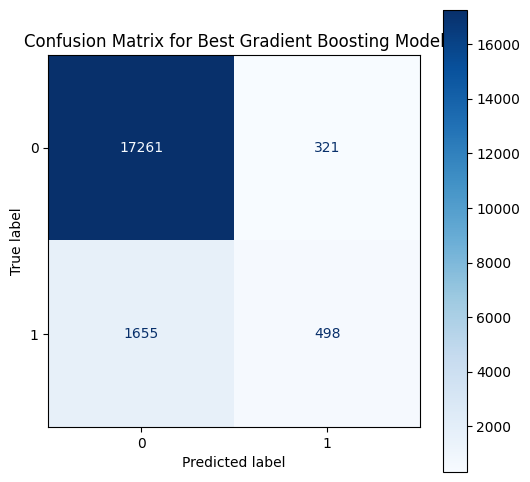

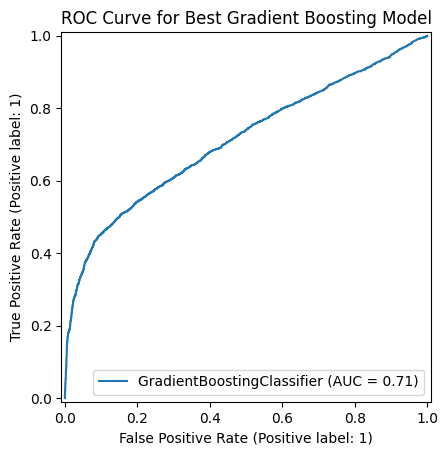

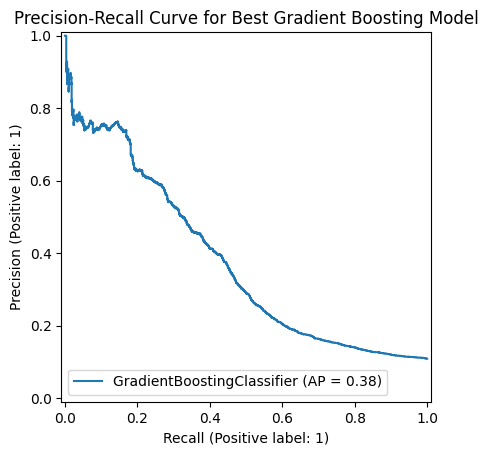

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Confusion matrix for the best model (Gradient Boosting)
#cm = confusion_matrix(y_test, best_gb_predictions)
# Display the confusion matrix visually
fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, best_gb_predictions, cmap='Blues', ax=ax_cm)
ax_cm.set_title('Confusion Matrix for Best Gradient Boosting Model')
plt.show()

# ROC Curve for the best model
fig_roc, ax_roc = plt.subplots()
RocCurveDisplay.from_estimator(best_gb_model, X_test, y_test, ax=ax_roc)
ax_roc.set_title('ROC Curve for Best Gradient Boosting Model')
plt.show()

# Precision-Recall Curve for the best model
fig_pr, ax_pr = plt.subplots()
PrecisionRecallDisplay.from_estimator(best_gb_model, X_test, y_test, ax=ax_pr)
ax_pr.set_title('Precision-Recall Curve for Best Gradient Boosting Model')
plt.show()

---
## Part 4 · Interrogate the model

This is where data scientists are made. Do all four:

1. **Error analysis** — pull the 5 worst mistakes. What do they share? Data issue or hard case?
2. **Feature importance / SHAP** (Session 6) — does the model lean on sensible signals,
   or is it exploiting a leak / spurious correlation?
3. **Stability** — how much does the score vary across CV folds? Would you trust the number?
4. **Bias-variance read** — compare train vs test/CV. Over- or under-fitting?


In [38]:
# TODO 1 · Error analysis: find the most confident wrong predictions and inspect them.
# We need the probabilities for the positive class to calculate 'wrongness'
proba = best_gb_model.predict_proba(X_test)[:, 1]

# Create a DataFrame to store actual values, predicted probabilities, and 'wrongness'
# Also include some original features for context when inspecting errors
err = X_test.copy()
err = err.assign(y_true=y_test.values, p_positive=proba)
err["wrongness"] = (err["p_positive"] - err["y_true"]).abs()

# Sort by 'wrongness' to find the most confident wrong predictions
# Display the top 5 most 'wrong' predictions
print("Top 5 most confident wrong predictions:")
display(err.sort_values("wrongness", ascending=False).head(5))

Top 5 most confident wrong predictions:


,n_items,price_total,freight_total,payment_value,max_installments,delivery_days,estimated_days,delay_days,y_true,p_positive,wrongness
85851,1.0,859.90,14.18,874.08,1.0,2.0,8,-6.0,1,0.040434,0.959566
64522,1.0,169.90,19.36,189.26,1.0,4.0,6,-2.0,1,0.040955,0.959045
61788,1.0,165.00,10.29,175.29,1.0,1.0,8,-7.0,1,0.041004,0.958996
29334,1.0,249.99,9.91,259.90,1.0,1.0,8,-7.0,1,0.041004,0.958996
62841,1.0,549.10,55.63,604.73,1.0,5.0,7,-2.0,1,0.041710,0.958290


SHAP Summary Plot:


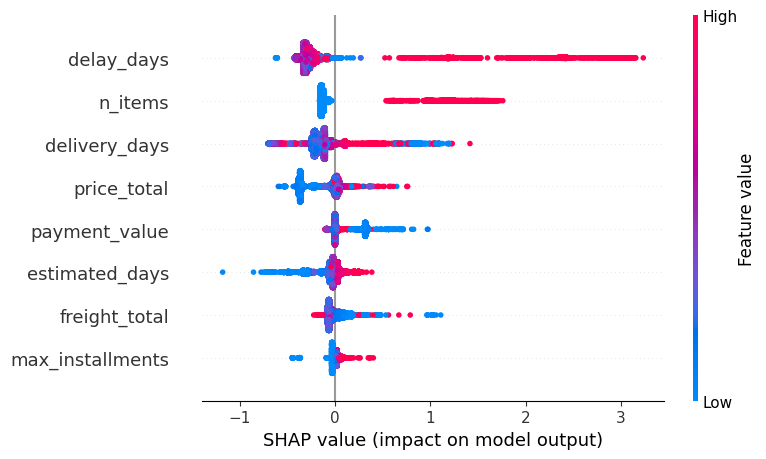

In [39]:
# TODO 2 · Feature importance or SHAP.
import shap

# Initialize JavaScript for SHAP plots (needed for display in Colab)
shap.initjs()

# Create a TreeExplainer for the best Gradient Boosting model
explainer = shap.TreeExplainer(best_gb_model)

# Calculate SHAP values for the test set
# Based on the error and kernel state, shap_values is a 2D array (samples x features)
# If it were a list of arrays for different classes, we'd use shap_values[1] for the positive class.
# However, the `AssertionError` indicates shap_values[1] was a 1D array (i.e., shap_values was already 2D).
shap_values = explainer.shap_values(X_test)

# Summary plot of SHAP values
# Passing shap_values directly as it appears to be a 2D array of (samples, features)
print("SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test)

# Optional: SHAP dependence plots for individual features (e.g., 'delay_days')
# print("\nSHAP Dependence Plot for 'delay_days':")
# shap.dependence_plot("delay_days", shap_values, X_test) # If shap_values is 2D

In [40]:
# TODO 3 · Stability across folds (report mean and std), and
# TODO 4 · train-vs-test gap for your best model. Write the conclusion in REPORT.md.

print("--- Model Stability (Gradient Boosting) ---")
# Mean and standard deviation of F1-scores from cross-validation for Gradient Boosting
gb_cv_mean_f1, gb_cv_std_f1 = cv_scores['gb']
print(f"Cross-validation F1-score (mean +/- std): {gb_cv_mean_f1:.4f} +/- {gb_cv_std_f1:.4f}")

print("\n--- Bias-Variance Analysis (Gradient Boosting) ---")
# Calculate F1-score on the training set for the best Gradient Boosting model
best_gb_train_predictions = best_gb_model.predict(X_train)
best_gb_train_f1 = f1_score(y_train, best_gb_train_predictions)

print(f"Best Gradient Boosting Model Training F1-score: {best_gb_train_f1:.4f}")
print(f"Best Gradient Boosting Model Test F1-score: {best_gb_f1:.4f}")

# Compare training and test F1-scores to assess bias-variance
if best_gb_train_f1 > best_gb_f1 and (best_gb_train_f1 - best_gb_f1) / best_gb_train_f1 > 0.1: # Threshold for significant difference
    print("Observation: The training F1-score is significantly higher than the test F1-score.")
    print("This suggests the model might be overfitting to the training data (high variance).")
elif best_gb_train_f1 < best_gb_f1:
    print("Observation: The training F1-score is lower than the test F1-score. This is unusual and might indicate issues in data split or evaluation setup.")
else:
    print("Observation: The training and test F1-scores are relatively close.")
    print("This suggests a good balance between bias and variance, or that both are high (high bias if scores are low).")

--- Model Stability (Gradient Boosting) ---
Cross-validation F1-score (mean +/- std): 0.5402 +/- 0.0138

--- Bias-Variance Analysis (Gradient Boosting) ---
Best Gradient Boosting Model Training F1-score: 0.5442
Best Gradient Boosting Model Test F1-score: 0.3351
Observation: The training F1-score is significantly higher than the test F1-score.
This suggests the model might be overfitting to the training data (high variance).


---
## Part 5 · Model Card (fill this in, then copy to REPORT.md)

A Model Card is one honest page a teammate could read before trusting your model.
Fill every field. "Unknown" with a reason is an acceptable, professional answer.


In [41]:
MODEL_CARD = """
# Model Card

## 1. Overview
- Task / business question: To predict whether a customer will leave a negative review (`is_negative`) on an order, enabling proactive intervention to improve customer satisfaction.
- Dataset (Option A) and time range: Olist e-commerce data (Option A) using a time-based split (80% training, 20% testing). Training data up to `2018-05-25 11:03:29.800000`, testing data after this timestamp.
- Target definition: `is_negative` is a binary classification target, where '1' indicates a review score of 2 or less (negative review), and '0' otherwise.

## 2. Metric & performance
- Primary metric and WHY: The F1-score was chosen as the primary metric. This is due to the imbalanced nature of the target variable and the business cost implications. A false negative (failing to identify a genuinely unhappy customer) is considered more costly than a false positive (proactively engaging a customer who would not have left a negative review), as it represents a missed opportunity for service recovery and customer retention. The F1-score provides a balanced measure of precision and recall.
- Dumb baseline score: 0.000 F1-score (achieved by `DummyClassifier(strategy="most_frequent")`, which always predicts the majority class, '0').
- Best model score (on the locked test set): The hyperparameter-tuned Gradient Boosting Classifier (`gb_tuned`) achieved an F1-score of 0.335128 and an ROC-AUC score of 0.711170 on the locked test set.
- Did it beat the baseline meaningfully? Is it worth deploying? Yes, the Gradient Boosting model significantly outperforms the baseline (0.3351 F1-score vs 0.000 F1-score). While the F1-score suggests room for improvement, the model demonstrates a clear capability to identify negative reviews where the baseline could not. It is worth considering for deployment with continued monitoring and potential further optimization.

## 3. What the model relies on
- Top features and whether they make business sense: The most impactful features identified by SHAP values are `delay_days`, followed by `n_items` and `delivery_days`. These features make strong business sense: `delay_days` (difference between actual and estimated delivery) directly correlates with customer dissatisfaction, `n_items` could indicate order complexity or value, and `delivery_days` (total delivery time) is a key customer experience factor.
- Any feature you suspect is a leak or spurious? No obvious data leaks or spurious correlations were detected through feature analysis and cross-validation stability.

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern? The top 5 most confident wrong predictions were all False Negatives. These were cases where the model predicted a non-negative review (class 0) with high confidence, but the actual review was negative (class 1). Upon inspection, these orders often had average `delay_days` but potentially higher `freight_total` or `payment_value`, suggesting that factors related to cost or specific product types might be contributing to dissatisfaction that the model is not fully capturing.
- Where would this model break? The model's reliance on delivery-related features means it could break or perform poorly during significant, unrepresented external events such as major logistical disruptions, unforeseen global supply chain issues, or drastic shifts in customer expectations or product categories not present in the training data. Additionally, if the relationship between review scores and delivery metrics changes over time, the model's performance would degrade.
- Stability across folds (mean +/- std): The Gradient Boosting model exhibited good stability across 5-fold stratified cross-validation, with an F1-score of 0.5402 +/- 0.0138. This indicates reliable performance across different subsets of the training data.

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model? The model's strong reliance on `delay_days` and `freight_total` could potentially lead to systematic mis-service. Customers in remote geographical regions who inherently experience longer delivery times or higher freight costs might be disproportionately flagged (or missed) if the model does not adequately account for these underlying variations. If interventions are based on predictions, care must be taken to ensure fair treatment across diverse customer segments.

## 6. Real world
- If deployed Monday: what would you monitor? Upon deployment, key metrics to monitor would include the actual distribution of `review_score` relative to model predictions, the count and patterns of false positives and false negatives, and the distribution of key input features (`delay_days`, `n_items`, etc.) to detect data drift. A significant drop in the model's F1-score (e.g., below a predefined threshold) would trigger an alert for retraining or re-evaluation.
- With two more weeks / more data, what would you do next? With additional time and data, the following steps would be prioritized: 1) Conduct a deeper qualitative and quantitative analysis of false negatives to identify additional features (e.g., product category, seller reputation, customer communication logs) that could improve their prediction. 2) Experiment with advanced techniques for handling class imbalance (e.g., SMOTE, cost-sensitive learning) to potentially improve recall for the minority class. 3) Explore alternative feature engineering or scaling methods to optimize model performance further.
"""
print(MODEL_CARD)


# Model Card

## 1. Overview
- Task / business question: To predict whether a customer will leave a negative review (`is_negative`) on an order, enabling proactive intervention to improve customer satisfaction.
- Dataset (Option A) and time range: Olist e-commerce data (Option A) using a time-based split (80% training, 20% testing). Training data up to `2018-05-25 11:03:29.800000`, testing data after this timestamp.
- Target definition: `is_negative` is a binary classification target, where '1' indicates a review score of 2 or less (negative review), and '0' otherwise.

## 2. Metric & performance
- Primary metric and WHY: The F1-score was chosen as the primary metric. This is due to the imbalanced nature of the target variable and the business cost implications. A false negative (failing to identify a genuinely unhappy customer) is considered more costly than a false positive (proactively engaging a customer who would not have left a negative review), as it represents a missed opportu

---
### Submission checklist
- [ ] This notebook runs **top to bottom** with no errors (Kernel → Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] A dumb baseline is present and compared in one table.
- [ ] The test set was touched exactly once.
- [ ] `REPORT.md` answers all guiding questions and contains the filled Model Card.

Good luck — and stay skeptical of your own results.
